## VGG Net

![alt text](https://blog.kakaocdn.net/dn/K990l/btqwDJ7C54R/664Ksm6gyTGBR1wK3YPDFk/img.png)

* VGG 네트워크는 레이어의 개수에 따라 VGG16, VGG19로 불림

* 모든 Convoulutional Layer에 3x3 필터 적용
* ReLu를 여러 번 사용할 수 있음
* Max-Pooling Layer, Global Average Pooling Layer 사용

* 함수로 구현

In [ ]:
import torch
import torch.nn as nn


###########################################
############## vgg model ##################
###########################################

class VGGNet(nn.Module):
    """VGG 스타일 분류 네트워크. in_shape는 Keras와 동일하게 (H, W, C)."""

    def __init__(self, in_shape=(224, 224, 3), n_classes=10):
        super().__init__()
        in_channels = in_shape[2]

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2),
        )
        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2),
        )
        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2),
        )
        # Block 4
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2),
        )
        # Block 5
        self.block5 = nn.Sequential(
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2),
        )

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512, 120),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(120, n_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


def create_vggnet(in_shape=(224, 224, 3), n_classes=10):
    model = VGGNet(in_shape=in_shape, n_classes=n_classes)
    print(model)
    return model


In [ ]:
model = create_vggnet(in_shape=(224, 224, 3), n_classes=10)

# 입력 텐서 형태: (batch, channel, height, width)
dummy = torch.randn(1, 3, 224, 224)
print('output shape:', model(dummy).shape)


## ResNet

![alt text](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FDexjQ%2Fbtq38lAARdU%2FTkAViEVM9Yj7MK3zr9K2E1%2Fimg.png)

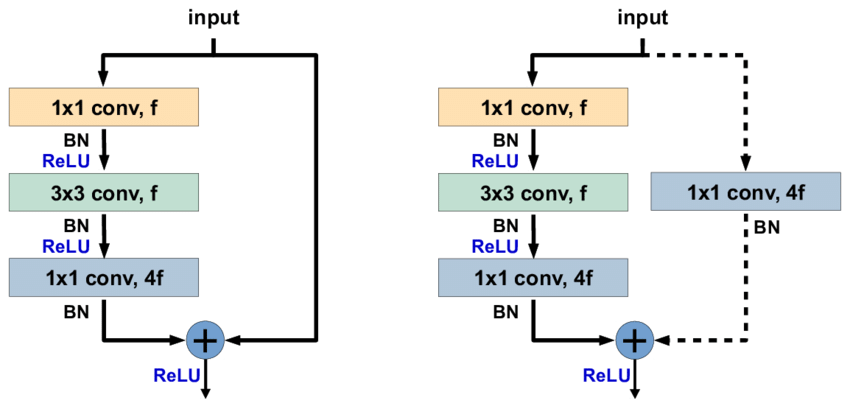

왼쪽이 identity_block , 오른쪽이 conv_block

In [ ]:
import torch
import torch.nn as nn


def _init_conv(conv: nn.Conv2d):
    nn.init.kaiming_normal_(conv.weight, mode='fan_out', nonlinearity='relu')
    if conv.bias is not None:
        nn.init.zeros_(conv.bias)


class IdentityBlock(nn.Module):
    """위의 block을 생성하는 클래스

    함수 입력 인자 설명
    middle_kernel_size: 중간에 위치하는 kernel 크기. identity block내에 있는 두개의 conv layer중 1x1 kernel이 아니고, 3x3 kernel임.
    3x3 커널이 이외에도 5x5 kernel도 지정할 수 있게 구성.
    filters: 3개 conv layer들의 filter개수를 list 형태로 입력 받음. 첫번째 원소는 첫번째 1x1 filter 개수, 두번째는 3x3 filter 개수, 세번째는 마지막 1x1 filter 개수
    stage: identity block들이 여러개가 결합되므로 이를 구분하기 위해서 설정. 동일한 filter수를 가지는 identity block들을  동일한 stage로 설정.
    block: 동일 stage내에서 identity block을 구별하기 위한 구분자
    """

    def __init__(self, in_channels, middle_kernel_size, filters, stage, block):
        super().__init__()
        filter1, filter2, filter3 = filters
        # filters로 list 형태로 입력된 filter 개수를 각각 filter1, filter2, filter3로 할당.
        # filter은 첫번째 1x1 filter 개수, filter2는 3x3 filter개수, filter3는 마지막 1x1 filter개수
        # ex) [64, 64, 256]

        conv_name_base = 'res' + str(stage) + block + '_branch'
        bn_name_base = 'bn' + str(stage) + block + '_branch'
        # 각 layer 별로 이름을 부여하기 위해서 name_base
        # stage는 각 layer 덩어리 총 4개의 stage로 구성

        # 첫번째 1x1 Conv->Batch Norm->Relu 수행.
        self.conv2a = nn.Conv2d(in_channels, filter1, kernel_size=1)
        # Batch Norm적용. PyTorch는 (N, C, H, W) 형태이므로 channel axis는 1
        self.bn2a = nn.BatchNorm2d(filter1)
        self.relu = nn.ReLU(inplace=True)

        # 두번째 3x3 Conv->Batch Norm->ReLU 수행
        padding = middle_kernel_size // 2
        self.conv2b = nn.Conv2d(filter1, filter2, kernel_size=middle_kernel_size, padding=padding)
        self.bn2b = nn.BatchNorm2d(filter2)

        # 마지막 1x1 Conv->Batch Norm 수행.
        self.conv2c = nn.Conv2d(filter2, filter3, kernel_size=1)
        self.bn2c = nn.BatchNorm2d(filter3)

        for conv in (self.conv2a, self.conv2b, self.conv2c):
            _init_conv(conv)

    def forward(self, input_tensor):
        x = self.conv2a(input_tensor)
        x = self.bn2a(x)
        x = self.relu(x)

        x = self.conv2b(x)
        x = self.bn2b(x)
        x = self.relu(x)

        x = self.conv2c(x)
        x = self.bn2c(x)

        # Residual Block 수행 결과와 input_tensor를 합한다.
        # 또는 x = input_tensor + x 와 같이 구현할 수도 있음.
        x = input_tensor + x
        # 마지막으로 identity block 내에서 최종 ReLU를 적용
        x = self.relu(x)
        return x


def identity_block(in_channels, middle_kernel_size, filters, stage, block):
    """Keras 함수형 API와 동일한 이름 — ResNet 조립 시 사용."""
    return IdentityBlock(in_channels, middle_kernel_size, filters, stage, block)


* identity block 확인

In [ ]:
#############################
##### 다음 stage layer ######
#############################

class ConvBlock(nn.Module):
    """
    함수 입력 인자 설명
    middle_kernel_size: 중간에 위치하는 kernel 크기. identity block내에 있는 두개의 conv layer중 1x1 kernel이 아니고, 3x3 kernel임.
                        3x3 커널 이외에도 5x5 kernel도 지정할 수 있게 구성.
    filters: 3개 conv layer들의 filter개수를 list 형태로 입력 받음. 첫번째 원소는 첫번째 1x1 filter 개수, 두번째는 3x3 filter 개수,
             세번째는 마지막 1x1 filter 개수
    stage: identity block들이 여러개가 결합되므로 이를 구분하기 위해서 설정. 동일한 filter수를 가지는 identity block들을  동일한 stage로 설정.
    block: 동일 stage내에서 identity block을 구별하기 위한 구분자
    strides: 입력 feature map의 크기를 절반으로 줄이기 위해서 사용. Default는 2이지만,
             첫번째 Stage의 첫번째 block에서는 이미 입력 feature map이 max pool로 절반이 줄어있는 상태이므로 다시 줄이지 않기 위해 1을 호출해야함
    """

    def __init__(self, in_channels, middle_kernel_size, filters, stage, block, strides=(2, 2)):
        super().__init__()
        filter1, filter2, filter3 = filters
        conv_name_base = 'res' + str(stage) + block + '_branch'
        bn_name_base = 'bn' + str(stage) + block + '_branch'
        stride = strides[0]

        self.conv2a = nn.Conv2d(in_channels, filter1, kernel_size=1, stride=stride)
        self.bn2a = nn.BatchNorm2d(filter1)
        self.relu = nn.ReLU(inplace=True)

        padding = middle_kernel_size // 2
        self.conv2b = nn.Conv2d(filter1, filter2, kernel_size=middle_kernel_size, padding=padding)
        self.bn2b = nn.BatchNorm2d(filter2)

        self.conv2c = nn.Conv2d(filter2, filter3, kernel_size=1)
        self.bn2c = nn.BatchNorm2d(filter3)

        # identity mapping
        self.shortcut_conv = nn.Conv2d(in_channels, filter3, kernel_size=1, stride=stride)
        self.shortcut_bn = nn.BatchNorm2d(filter3)

        for conv in (self.conv2a, self.conv2b, self.conv2c, self.shortcut_conv):
            _init_conv(conv)

    def forward(self, input_tensor):
        x = self.conv2a(input_tensor)
        x = self.bn2a(x)
        x = self.relu(x)

        x = self.conv2b(x)
        x = self.bn2b(x)
        x = self.relu(x)

        x = self.conv2c(x)
        x = self.bn2c(x)

        shortcut = self.shortcut_conv(input_tensor)
        shortcut = self.shortcut_bn(shortcut)

        x = x + shortcut
        x = self.relu(x)
        return x


def conv_block(in_channels, middle_kernel_size, filters, stage, block, strides=(2, 2)):
    return ConvBlock(in_channels, middle_kernel_size, filters, stage, block, strides=strides)
# 위의 block과 동일한데, stride만 다르다


In [ ]:
##################################
####### 첫번째 층에서 ############
######## feature 줄이기 ##########
##################################


class FirstConv(nn.Module):
  def __init__(self, in_channels=3):
    super().__init__()
    self.pad1 = nn.ZeroPad2d(3)
    self.conv = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=0)
    self.bn = nn.BatchNorm2d(64)
    self.relu = nn.ReLU(inplace=True)
    self.pad2 = nn.ZeroPad2d(1)
    self.pool = nn.MaxPool2d(kernel_size=3, stride=2)

    _init_conv(self.conv)

  def forward(self, x):
    x = self.pad1(x)
    x = self.conv(x)
    x = self.bn(x)
    x = self.relu(x)
    x = self.pad2(x)
    x = self.pool(x)
    return x


def do_first_conv(in_channels=3):
  return FirstConv(in_channels=in_channels)


model = do_first_conv(in_channels=3)
input_tensor = torch.randn(1, 3, 224, 224)
output = model(input_tensor)
print(model)
print('output shape:', output.shape)


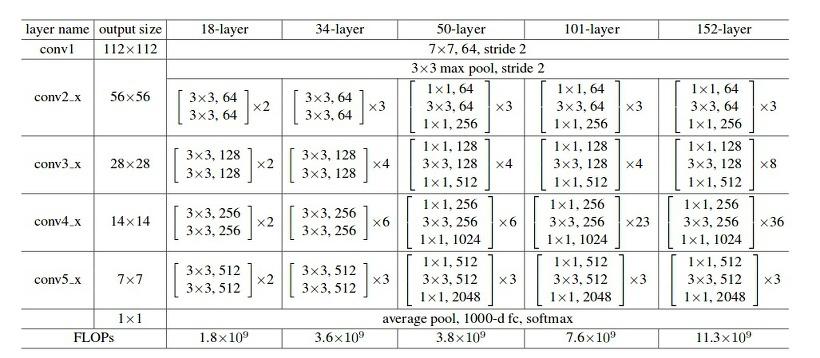

In [ ]:
#########################################
########### ResNet 구현 #################
#########################################


class ResNet50(nn.Module):
    def __init__(self, in_shape=(224, 224, 3), n_classes=10):
        super().__init__()
        in_channels = in_shape[2]

        layers = [
            do_first_conv(in_channels=in_channels),
            # stage 2의 conv_block과 identity block 생성. stage2의 첫번째 conv_block은 strides를 1로 하여 크기를 줄이지 않음.
            conv_block(64, 3, [64, 64, 256], stage=2, block='a', strides=(1, 1)),
            identity_block(256, 3, [64, 64, 256], stage=2, block='b'),
            identity_block(256, 3, [64, 64, 256], stage=2, block='c'),
            # stage 3의 conv_block과 identity block 생성. stage3의 첫번째 conv_block은 strides를 2(default)로 하여 크기를 줄임
            conv_block(256, 3, [128, 128, 512], stage=3, block='a'),
            identity_block(512, 3, [128, 128, 512], stage=3, block='b'),
            identity_block(512, 3, [128, 128, 512], stage=3, block='c'),
            identity_block(512, 3, [128, 128, 512], stage=3, block='d'),
            # stage 4의 conv_block과 identity block 생성. stage4의 첫번째 conv_block은 strides를 2(default)로 하여 크기를 줄임
            conv_block(512, 3, [256, 256, 1024], stage=4, block='a'),
            identity_block(1024, 3, [256, 256, 1024], stage=4, block='b'),
            identity_block(1024, 3, [256, 256, 1024], stage=4, block='c'),
            identity_block(1024, 3, [256, 256, 1024], stage=4, block='d'),
            identity_block(1024, 3, [256, 256, 1024], stage=4, block='e'),
            identity_block(1024, 3, [256, 256, 1024], stage=4, block='f'),
            # stage 5의 conv_block과 identity block 생성. stage5의 첫번째 conv_block은 strides를 2(default)로 하여 크기를 줄임
            conv_block(1024, 3, [512, 512, 2048], stage=5, block='a'),
            identity_block(2048, 3, [512, 512, 2048], stage=5, block='b'),
            identity_block(2048, 3, [512, 512, 2048], stage=5, block='c'),
        ]
        self.features = nn.Sequential(*layers)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(2048, 200),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(200, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        # classification dense layer와 연결 전 GlobalAveragePooling 수행
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


def create_resnet(in_shape=(224, 224, 3), n_classes=10):
    model = ResNet50(in_shape=in_shape, n_classes=n_classes)
    print(model)
    return model


In [ ]:
model = create_resnet(in_shape=(224, 224, 3), n_classes=10)

dummy = torch.randn(1, 3, 224, 224)
print('output shape:', model(dummy).shape)


## 모델 간단하게 만들기

https://pytorch.org/vision/stable/models.html


In [ ]:
# Resnet
from torchvision.models import resnet50, ResNet50_Weights

model = resnet50(weights=ResNet50_Weights.DEFAULT)
print(model)


In [ ]:
# vgg19
from torchvision.models import vgg19, VGG19_Weights

model = vgg19(weights=VGG19_Weights.DEFAULT)
print(model)


In [ ]:
# Inception
from torchvision.models import inception_v3, Inception_V3_Weights

model = inception_v3(weights=Inception_V3_Weights.DEFAULT)
print(model)


In [ ]:
# EfficientNet
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
print(model)


https://docs.pytorch.org/vision/main/models.html